In [205]:
#image import for processing

from PIL import Image
import numpy as np
from IPython.display import display

def import_for_pillow(path):
    img = Image.open(path)

    print(f"   Format: {img.format}")
    print(f"   Size: {img.size}")  
    print(f"   Mode: {img.mode}")  

    if img.mode != 'RGB':
        img = img.convert('RGB')

    img_array = np.array(img)

    return img, img_array

pil_img, array = import_for_pillow("./bees/samples_south/EAoR1r1m_ind01.dw.png")
# display(pil_img)

   Format: PNG
   Size: (2048, 1536)
   Mode: RGB


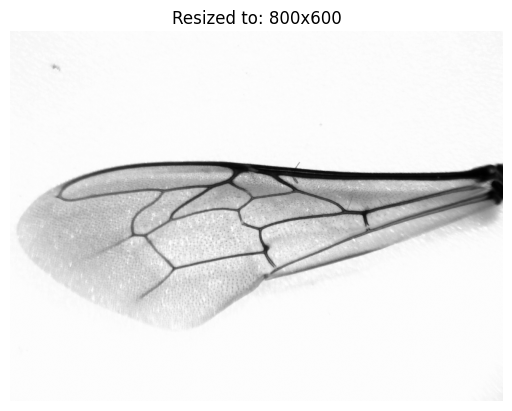

In [206]:
# Grayscaling and downsizing the image 
import cv2

def smart_resize_grayscale(img, max_dimension=800):
    
    # Convert to Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Smart Resize
    height, width = gray.shape
    scale = min(max_dimension / height, max_dimension / width)
    
    # Calculate new dimensions (rounded to nearest integer)
    new_width = int(width * scale)
    new_height = int(height * scale)

    # Use INTER_LANCZOS4 for best detail preservation when downsizing
    # INTER_AREA is also good for shrinking images significantly
    resized = cv2.resize(gray, (new_width, new_height), interpolation=cv2.INTER_LANCZOS4)

    return resized

# Usage
image_gray = smart_resize_grayscale(array, max_dimension=800)

# Display to verify
import matplotlib.pyplot as plt
plt.imshow(image_gray, cmap='gray')
plt.axis('off')
plt.title(f"Resized to: {image_gray.shape[1]}x{image_gray.shape[0]}")
plt.show()

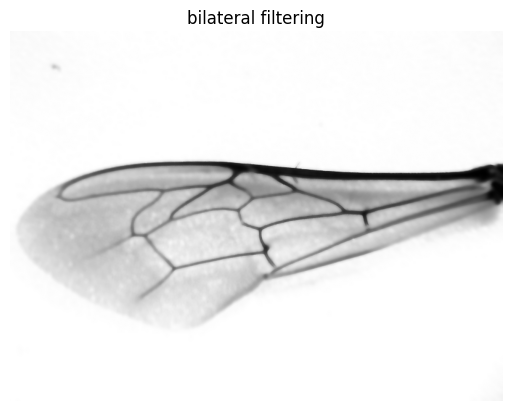

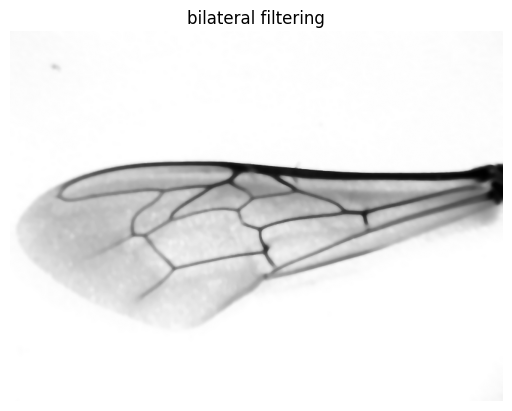

In [207]:
filtered_image = cv2.bilateralFilter(image_gray, d=9, sigmaColor=75, sigmaSpace=75)
plt.imshow(filtered_image, cmap='gray')
plt.axis('off')
plt.title("bilateral filtering")
plt.show()

filtered_median = cv2.medianBlur(filtered_image, 5)
plt.imshow(filtered_median, cmap='gray')
plt.axis('off')
plt.title("bilateral filtering")
plt.show()



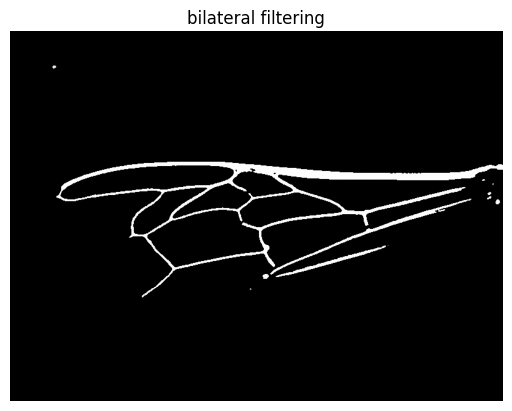

In [208]:
blur1 = cv2.GaussianBlur(image_gray, (0, 0), sigmaX=7)
blur2 = cv2.GaussianBlur(image_gray, (0, 0), sigmaX=0.5)

# Calculate Difference of Gaussians
dog = cv2.subtract(blur1, blur2)

# Optional: Take absolute value to capture both edges and dark/bright transitions
dog_abs = cv2.convertScaleAbs(dog)

# Apply thresholding to get binary edge map
# Use Otsu's thresholding for automatic cutoff or a fixed value
_, thresh = cv2.threshold(dog_abs, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

bilateral = cv2.bilateralFilter(thresh, d=30, sigmaColor=75, sigmaSpace=75)


median = cv2.medianBlur(bilateral, 3)


plt.imshow(median, cmap='gray')
plt.axis('off')
plt.title("bilateral filtering")
plt.show()

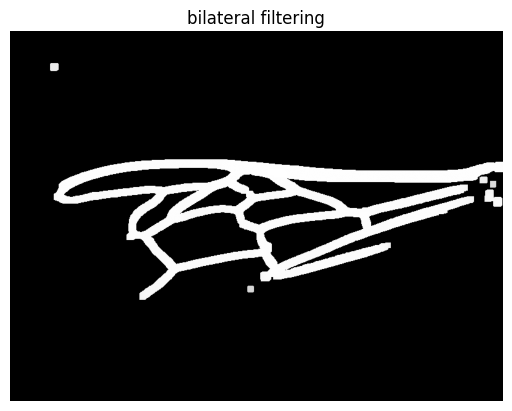

In [209]:

# Define kernel (e.g., 5x5 square)
kernel = np.ones((5,5), np.uint8)

# Apply dilation
dilated_img = cv2.dilate(median, kernel, iterations=2)

plt.imshow(dilated_img, cmap='gray')
plt.axis('off')
plt.title("bilateral filtering")
plt.show()

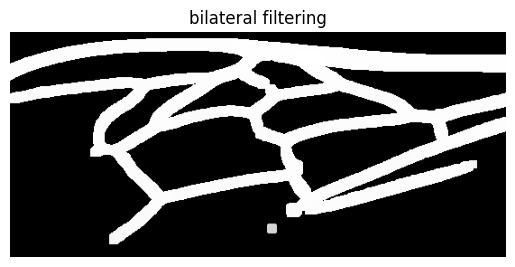

In [213]:
y1, y2 = 200, 450
x1, x2 = 100, 650

# Crop using slicing
cropped_img = dilated_img[y1:y2, x1:x2]

plt.imshow(cropped_img, cmap='gray')
plt.axis('off')
plt.title("bilateral filtering")
plt.show()

(np.float64(-0.5), np.float64(549.5), np.float64(249.5), np.float64(-0.5))

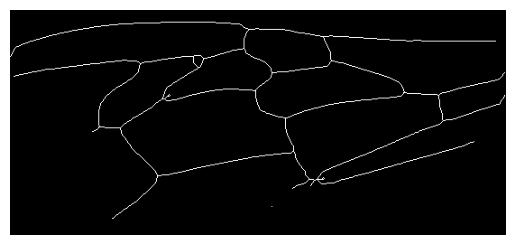

In [214]:
from skimage.morphology import skeletonize

skeleton = skeletonize(cropped_img).astype(np.uint8) * 255

plt.imshow(skeleton, cmap='gray')
plt.axis('off')

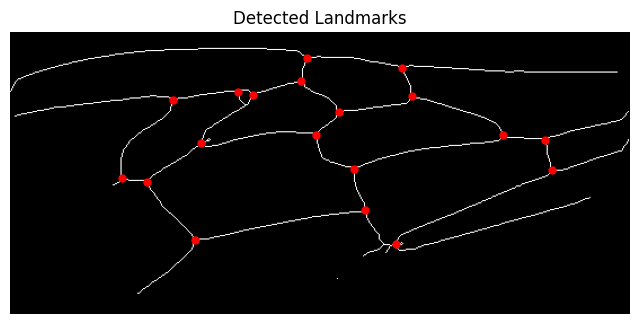

In [215]:
from skimage.morphology import skeletonize
from skimage.feature import corner_harris, corner_peaks

# Convert to binary
binary = (cropped_img > 0).astype(np.uint8)
skeleton = skeletonize(binary)

# Detect corners/junctions using Harris corner detector
coords = corner_peaks(corner_harris(skeleton), min_distance=10, threshold_rel=0.3)

# Filter points
junction_points = []
for coord in coords:
    # Check if it's a line junction (has multiple directions)
    y, x = coord
    window = skeleton[y-3:y+4, x-3:x+4]
    if window.shape == (7, 7):
        # Count transitions to determine if it's a junction
        transitions = 0
        for angle in range(0, 180, 30):
            # Check along different directions
            pass  # Simplified - you can implement direction analysis
    
    junction_points.append(coord)

# Visualize
plt.figure(figsize=(8, 8))
plt.imshow(skeleton, cmap='gray')
plt.plot([p[1] for p in junction_points], [p[0] for p in junction_points], 'ro', markersize=5)
plt.title('Detected Landmarks')
plt.axis('off')
plt.show()